# Notebook 07: Notable Events

**One Sensor, One Year — Edition 2: US Grid**

Every sensor tells a story through its extremes. This notebook finds the record days, the holidays that visibly bend the grid, and the anomalies — the raw material for the essay and the event annotations on every future chart.

**Input:** `../data/processed/us48_2025_derived.csv` (daily totals + CO₂ + intensity from N03)

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
df = pd.read_csv(PROCESSED / 'us48_2025_derived.csv', parse_dates=['date'], index_col='date').sort_index()
df['day_name'] = df.index.strftime('%A')
df['month'] = df.index.month

# Derive totals (re-compute to ensure consistency with N05 if run in any order)
FOSSIL_COLS = [c for c in ['COL', 'NG', 'OIL', 'OTH'] if c in df.columns]
CLEAN_COLS  = [c for c in ['NUC', 'WND', 'SUN', 'WAT', 'GEO', 'SNB', 'WNB'] if c in df.columns]
GEN_COLS    = FOSSIL_COLS + CLEAN_COLS + [c for c in ['UNK'] if c in df.columns]
if 'total_gen' not in df.columns:
    df['total_gen'] = df[GEN_COLS].sum(axis=1)
if 'clean_share' not in df.columns:
    df['clean_share'] = df[CLEAN_COLS].sum(axis=1) / df['total_gen'] * 100

print(f'Rows: {len(df)}, cols: {len(df.columns)}')

Rows: 365, cols: 45


## 1. Records — the extremes of 2025

Headline records across generation, per-fuel peaks, clean share, CO₂, and intensity.

In [2]:
records = []

metrics = [
    ('total_gen', 'Highest total generation', 'max', 'GWh'),
    ('total_gen', 'Lowest total generation', 'min', 'GWh'),
    ('COL', 'Highest coal day', 'max', 'GWh'),
    ('COL', 'Lowest coal day', 'min', 'GWh'),
    ('NG', 'Highest gas day', 'max', 'GWh'),
    ('WND', 'Highest wind day', 'max', 'GWh'),
    ('SUN', 'Highest solar day', 'max', 'GWh'),
    ('NUC', 'Highest nuclear day', 'max', 'GWh'),
    ('WAT', 'Highest hydro day', 'max', 'GWh'),
    ('clean_share', 'Cleanest grid day', 'max', '%'),
    ('clean_share', 'Dirtiest grid day', 'min', '%'),
    ('co2_total', 'Highest CO2 day', 'max', 'kt'),
    ('co2_total', 'Lowest CO2 day', 'min', 'kt'),
    ('intensity', 'Lowest emissions intensity', 'min', 'tCO2/MWh'),
    ('intensity', 'Highest emissions intensity', 'max', 'tCO2/MWh'),
]

print('RECORDS — US48 2025')
print('=' * 90)
print(f'{"Record":35s} {"Date":>12s} {"Day":>10s} {"Value":>18s}')
print('-' * 90)

for col, label, op, unit in metrics:
    if col not in df.columns:
        continue
    idx = df[col].idxmin() if op == 'min' else df[col].idxmax()
    row = df.loc[idx]
    val = row[col]
    if unit == 'GWh':
        val = val / 1e3
    elif unit == 'kt':
        val = val / 1e3
    val_str = f'{val:,.1f} {unit}' if unit in {'GWh', 'kt'} else (f'{val:.1f}%' if unit == '%' else f'{val:.3f}')
    print(f'{label:35s} {idx.strftime("%b %d"):>12s} {row["day_name"]:>10s} {val_str:>18s}')
    records.append({'metric': label, 'date': idx.strftime('%Y-%m-%d'), 'day': row['day_name'], 'value': val_str})

RECORDS — US48 2025
Record                                      Date        Day              Value
------------------------------------------------------------------------------------------
Highest total generation                  Jul 29    Tuesday       15,221.9 GWh
Lowest total generation                   May 04     Sunday        9,620.2 GWh
Highest coal day                          Jan 21    Tuesday        3,317.4 GWh
Lowest coal day                           Mar 15   Saturday        1,322.2 GWh
Highest gas day                           Jul 29    Tuesday        7,037.1 GWh
Highest wind day                          Jun 21   Saturday        2,219.9 GWh
Highest solar day                         Jul 28     Monday        1,059.0 GWh
Highest nuclear day                       Dec 20   Saturday        2,378.5 GWh
Highest hydro day                         May 16     Friday          889.4 GWh
Cleanest grid day                         Apr 13     Sunday              55.8%
Dirtiest grid day   

## 2. US holidays — does the grid rest?

Major US federal holidays + notable dates. % vs. annual average generation tells us which ones the grid actually notices.

In [3]:
# Major US 2025 dates (federal holidays + high-profile cultural markers)
holidays = [
    ('2025-01-01', "New Year's Day"),
    ('2025-01-20', 'MLK Jr. Day / Inauguration Day'),
    ('2025-02-17', "Presidents' Day"),
    ('2025-04-18', 'Good Friday'),
    ('2025-05-26', 'Memorial Day'),
    ('2025-07-04', 'Independence Day'),
    ('2025-09-01', 'Labor Day'),
    ('2025-10-13', 'Columbus / Indigenous Peoples Day'),
    ('2025-11-11', 'Veterans Day'),
    ('2025-11-27', 'Thanksgiving'),
    ('2025-11-28', 'Black Friday'),
    ('2025-12-25', 'Christmas Day'),
    ('2025-12-31', "New Year's Eve"),
]

annual_avg = df['total_gen'].mean()
print(f'Annual avg daily generation: {annual_avg/1e3:,.0f} GWh/day')
print()
print('Holiday Grid Impact — 2025')
print('=' * 110)
print(f'{"Holiday":35s} {"Date":>10s} {"Day":>11s} {"Total GWh":>10s} {"vs Avg":>8s} {"Coal%":>7s} {"NG%":>7s} {"Clean%":>7s}')
print('-' * 110)

for date_str, name in holidays:
    ts = pd.Timestamp(date_str)
    if ts not in df.index:
        continue
    row = df.loc[ts]
    total_gwh = row['total_gen'] / 1e3
    diff = (row['total_gen'] / annual_avg - 1) * 100
    coal_pct = row['COL'] / row['total_gen'] * 100
    ng_pct   = row['NG']  / row['total_gen'] * 100
    clean_pct = row['clean_share']
    print(f'{name:35s} {date_str[5:]:>10s} {row["day_name"]:>11s} {total_gwh:10,.0f} {diff:+7.1f}% {coal_pct:6.1f}% {ng_pct:6.1f}% {clean_pct:6.1f}%')

Annual avg daily generation: 11,695 GWh/day

Holiday Grid Impact — 2025
Holiday                                   Date         Day  Total GWh   vs Avg   Coal%     NG%  Clean%
--------------------------------------------------------------------------------------------------------------
New Year's Day                           01-01   Wednesday     10,426   -10.9%   17.4%   35.1%   46.3%
MLK Jr. Day / Inauguration Day           01-20      Monday     13,827   +18.2%   23.6%   39.0%   35.3%
Presidents' Day                          02-17      Monday     12,161    +4.0%   21.2%   34.7%   42.9%
Good Friday                              04-18      Friday     10,208   -12.7%   13.9%   30.4%   54.6%
Memorial Day                             05-26      Monday     10,409   -11.0%   14.3%   37.0%   47.6%
Independence Day                         07-04      Friday     12,855    +9.9%   18.2%   39.4%   41.0%
Labor Day                                09-01      Monday     11,320    -3.2%   15.6%   45.2%  

## 3. Thanksgiving week — the US analog to Diwali

Thanksgiving (fourth Thursday of November) plus Black Friday is the visible low-demand cluster of the US year. Commercial load drops, residential cooking load surges briefly. Let's zoom in.

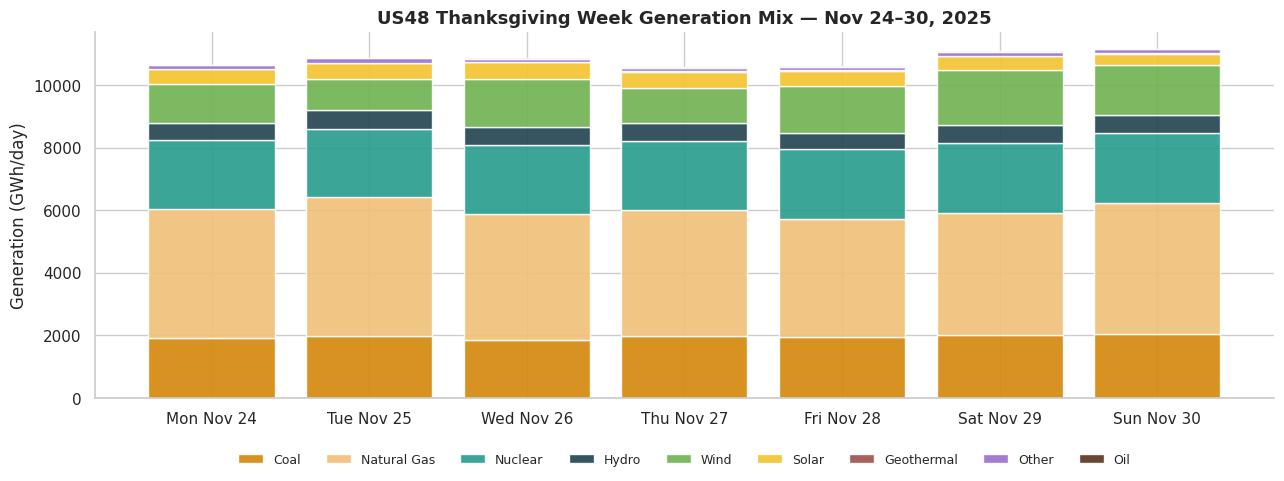

Thanksgiving  (Nov 27): 10,577 GWh (-9.6% vs avg)
Black Friday  (Nov 28): 10,613 GWh (-9.3% vs avg)


In [4]:
tw_mask = (df.index >= '2025-11-24') & (df.index <= '2025-11-30')
week = df[tw_mask].copy()

stack_cols = [c for c in ['COL', 'NG', 'NUC', 'WAT', 'WND', 'SUN', 'GEO', 'OTH', 'OIL'] if c in week.columns]
stack_colors = {'COL': '#D4890E', 'NG': '#F0C078', 'NUC': '#2A9D8F', 'WAT': '#264653',
                'WND': '#72B352', 'SUN': '#F4C430', 'GEO': '#A0524D', 'OTH': '#9B72CF', 'OIL': '#5A3825'}
stack_labels = {'COL': 'Coal', 'NG': 'Natural Gas', 'NUC': 'Nuclear', 'WAT': 'Hydro',
                'WND': 'Wind', 'SUN': 'Solar', 'GEO': 'Geothermal', 'OTH': 'Other', 'OIL': 'Oil'}

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(week))
day_labels = [d.strftime('%a %b %d') for d in week.index]
for col in stack_cols:
    vals = (week[col] / 1e3).values
    ax.bar(day_labels, vals, bottom=bottom, color=stack_colors[col], label=stack_labels[col], alpha=0.92)
    bottom += vals
ax.set_ylabel('Generation (GWh/day)')
ax.set_title('US48 Thanksgiving Week Generation Mix — Nov 24–30, 2025',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=9, frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

thanksgiving = df.loc['2025-11-27']
black_friday = df.loc['2025-11-28']
print(f'Thanksgiving  (Nov 27): {thanksgiving["total_gen"]/1e3:,.0f} GWh ({(thanksgiving["total_gen"]/annual_avg-1)*100:+.1f}% vs avg)')
print(f'Black Friday  (Nov 28): {black_friday["total_gen"]/1e3:,.0f} GWh ({(black_friday["total_gen"]/annual_avg-1)*100:+.1f}% vs avg)')

## 4. Top-10 highest demand days

Summer AC peak is the stress test of the US grid.

In [5]:
top10 = df.nlargest(10, 'total_gen')[['day_name', 'total_gen', 'COL', 'NG', 'WND', 'SUN', 'clean_share']]

print('Top-10 Highest Demand Days — US48 2025')
print('=' * 100)
print(f'{"#":>3s} {"Date":>12s} {"Day":>11s} {"Total GWh":>10s} {"Coal":>8s} {"Gas":>8s} {"Wind":>8s} {"Solar":>8s} {"Clean%":>7s}')
print('-' * 100)
for i, (idx, row) in enumerate(top10.iterrows(), 1):
    print(f'{i:3d} {idx.strftime("%b %d"):>12s} {row["day_name"]:>11s} {row["total_gen"]/1e3:10,.0f} {row["COL"]/1e3:8,.0f} {row["NG"]/1e3:8,.0f} {row["WND"]/1e3:8,.0f} {row["SUN"]/1e3:8,.0f} {row["clean_share"]:6.1f}%')

print(f'\nAll top 10 months: {", ".join(sorted(set(d.strftime("%B") for d in top10.index)))}')

Top-10 Highest Demand Days — US48 2025
  #         Date         Day  Total GWh     Coal      Gas     Wind    Solar  Clean%
----------------------------------------------------------------------------------------------------
  1       Jul 29     Tuesday     15,222    2,898    7,037      962    1,042   33.0%
  2       Jul 30   Wednesday     15,064    2,927    7,025      801    1,025   32.2%
  3       Jan 22   Wednesday     14,956    3,039    6,090    1,722      515   35.9%
  4       Jan 21     Tuesday     14,914    3,317    6,174    1,381      459   33.4%
  5       Jul 28      Monday     14,822    2,766    6,548    1,234    1,059   35.6%
  6       Jun 24     Tuesday     14,697    2,782    6,403    1,156    1,022   35.5%
  7       Jul 25      Friday     14,606    2,881    6,713      830      964   32.9%
  8       Jun 25   Wednesday     14,579    2,705    6,385    1,201      978   35.5%
  9       Jul 16   Wednesday     14,544    2,798    6,278    1,273      921   36.0%
 10       Aug 12    

## 5. Bottom-10 lowest demand days

Shoulder-season days when neither heating nor cooling drives load — typically spring weekends + holiday pockets.

In [6]:
bot10 = df.nsmallest(10, 'total_gen')[['day_name', 'total_gen', 'COL', 'NG', 'WND', 'SUN', 'clean_share']]

print('Bottom-10 Lowest Demand Days — US48 2025')
print('=' * 100)
print(f'{"#":>3s} {"Date":>12s} {"Day":>11s} {"Total GWh":>10s} {"Coal":>8s} {"Gas":>8s} {"Wind":>8s} {"Solar":>8s} {"Clean%":>7s}')
print('-' * 100)
for i, (idx, row) in enumerate(bot10.iterrows(), 1):
    print(f'{i:3d} {idx.strftime("%b %d"):>12s} {row["day_name"]:>11s} {row["total_gen"]/1e3:10,.0f} {row["COL"]/1e3:8,.0f} {row["NG"]/1e3:8,.0f} {row["WND"]/1e3:8,.0f} {row["SUN"]/1e3:8,.0f} {row["clean_share"]:6.1f}%')

print(f'\nDay-of-week pattern: {", ".join(bot10["day_name"].value_counts().to_dict().keys())}')

Bottom-10 Lowest Demand Days — US48 2025
  #         Date         Day  Total GWh     Coal      Gas     Wind    Solar  Clean%
----------------------------------------------------------------------------------------------------
  1       May 04      Sunday      9,620    1,403    3,375    1,247      774   49.1%
  2       May 11      Sunday      9,641    1,419    3,408    1,014      904   48.8%
  3       Apr 20      Sunday      9,651    1,414    3,171    1,479      814   51.2%
  4       Mar 16      Sunday      9,653    1,390    3,287    1,490      619   50.5%
  5       Apr 13      Sunday      9,732    1,354    2,840    1,832      839   55.8%
  6       Mar 23      Sunday      9,747    1,409    2,968    1,919      649   53.3%
  7       Nov 02      Sunday      9,754    1,579    3,614    1,215      737   45.7%
  8       Apr 27      Sunday      9,778    1,330    3,197    1,680      833   52.6%
  9       Nov 16      Sunday      9,791    1,620    3,648    1,231      566   45.1%
 10       Mar 30  

## 6. Anomaly detection — unusual days vs monthly average

Which days deviate most from their own month's norm? Holidays and weather events both surface here.

In [7]:
monthly_avg = df.groupby('month')['total_gen'].transform('mean')
df['anomaly_pct'] = (df['total_gen'] - monthly_avg) / monthly_avg * 100

drops = df.nsmallest(10, 'anomaly_pct')[['day_name', 'total_gen', 'anomaly_pct']]
print('Biggest negative anomalies (vs monthly avg):')
for idx, row in drops.iterrows():
    print(f'  {idx.strftime("%b %d")} ({row["day_name"]:>9s}): {row["total_gen"]/1e3:,.0f} GWh ({row["anomaly_pct"]:+.1f}%)')

print()
spikes = df.nlargest(10, 'anomaly_pct')[['day_name', 'total_gen', 'anomaly_pct']]
print('Biggest positive anomalies (vs monthly avg):')
for idx, row in spikes.iterrows():
    print(f'  {idx.strftime("%b %d")} ({row["day_name"]:>9s}): {row["total_gen"]/1e3:,.0f} GWh ({row["anomaly_pct"]:+.1f}%)')

Biggest negative anomalies (vs monthly avg):
  Jun 01 (   Sunday): 10,474 GWh (-17.5%)
  Jan 01 (Wednesday): 10,426 GWh (-16.7%)
  Dec 25 ( Thursday): 10,005 GWh (-15.1%)
  Aug 31 (   Sunday): 11,157 GWh (-15.1%)
  Dec 26 (   Friday): 10,278 GWh (-12.8%)
  Aug 30 ( Saturday): 11,481 GWh (-12.6%)
  Jun 02 (   Monday): 11,207 GWh (-11.7%)
  Dec 27 ( Saturday): 10,496 GWh (-10.9%)
  Jan 31 (   Friday): 11,163 GWh (-10.8%)
  May 04 (   Sunday): 9,620 GWh (-10.6%)

Biggest positive anomalies (vs monthly avg):
  Jan 22 (Wednesday): 14,956 GWh (+19.5%)
  Jan 21 (  Tuesday): 14,914 GWh (+19.2%)
  Feb 20 ( Thursday): 13,910 GWh (+19.2%)
  Feb 21 (   Friday): 13,704 GWh (+17.4%)
  Dec 15 (   Monday): 13,773 GWh (+16.9%)
  Jun 24 (  Tuesday): 14,697 GWh (+15.8%)
  Feb 19 (Wednesday): 13,488 GWh (+15.6%)
  Jun 25 (Wednesday): 14,579 GWh (+14.9%)
  Jan 23 ( Thursday): 14,250 GWh (+13.9%)
  Jun 23 (   Monday): 14,431 GWh (+13.7%)


## 7. Annotated event timeline

Year overview with the events that matter. Summer shaded. Seasonal narrative.

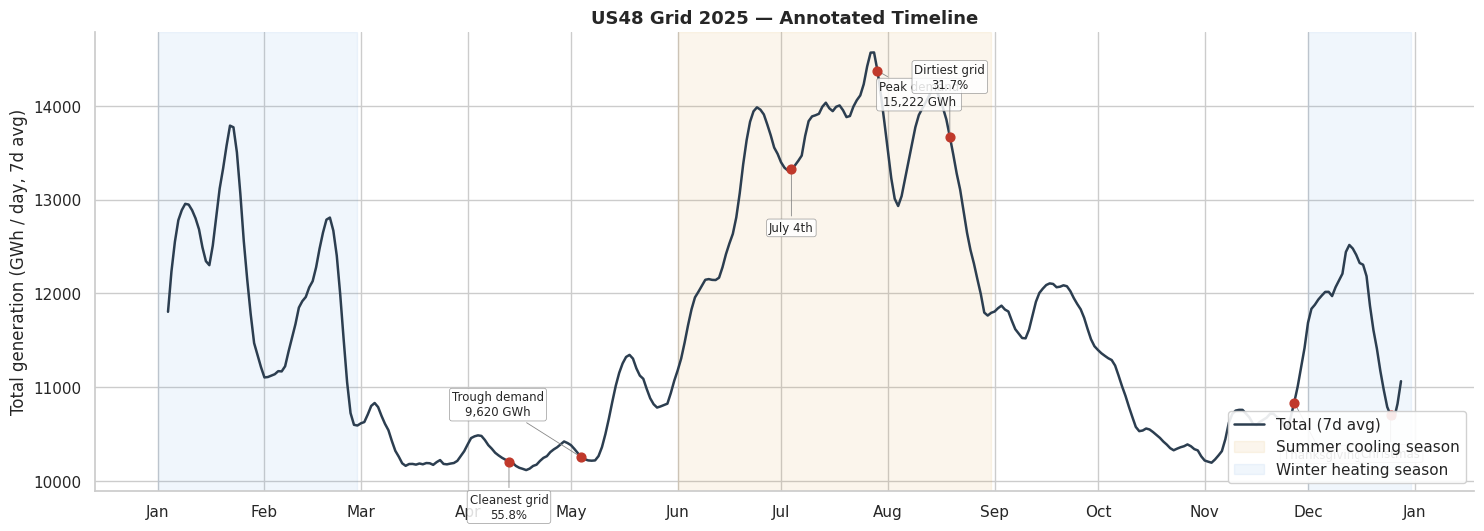

In [8]:
smooth = df['total_gen'].rolling(7, center=True).mean() / 1e3

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.plot(smooth.index, smooth.values, color='#2C3E50', linewidth=1.8, label='Total (7d avg)')

# Shade summer (Jun-Aug) as cooling-driven peak
ax.axvspan(pd.Timestamp('2025-06-01'), pd.Timestamp('2025-08-31'),
           color='#D4890E', alpha=0.08, label='Summer cooling season')
# Shade winter heating (Dec-Feb)
ax.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-02-28'),
           color='#4A90D9', alpha=0.08)
ax.axvspan(pd.Timestamp('2025-12-01'), pd.Timestamp('2025-12-31'),
           color='#4A90D9', alpha=0.08, label='Winter heating season')

# Annotate key events
peak_idx = df['total_gen'].idxmax()
trough_idx = df['total_gen'].idxmin()
cleanest = df['clean_share'].idxmax()
dirtiest = df['clean_share'].idxmin()

events = [
    (peak_idx, f'Peak demand\n{df["total_gen"].max()/1e3:,.0f} GWh', 30, -25),
    (trough_idx, f'Trough demand\n{df["total_gen"].min()/1e3:,.0f} GWh', -60, 30),
    (cleanest, f'Cleanest grid\n{df["clean_share"].max():.1f}%', 0, -40),
    (dirtiest, f'Dirtiest grid\n{df["clean_share"].min():.1f}%', 0, 35),
    (pd.Timestamp('2025-07-04'), 'July 4th', 0, -45),
    (pd.Timestamp('2025-11-27'), 'Thanksgiving', 20, -40),
    (pd.Timestamp('2025-12-25'), 'Christmas', 0, -30),
]

for ts, label, dx, dy in events:
    if ts not in smooth.index:
        continue
    y_val = smooth.loc[ts]
    ax.scatter([ts], [y_val], color='#C0392B', s=40, zorder=5)
    ax.annotate(label, xy=(ts, y_val), xytext=(dx, dy), textcoords='offset points',
                fontsize=8.5, ha='center',
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.6),
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#888', lw=0.5, alpha=0.85))

ax.set_ylabel('Total generation (GWh / day, 7d avg)')
ax.set_title('US48 Grid 2025 — Annotated Timeline', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(loc='lower right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

## 8. Export events JSON

Compact JSON for downstream notebooks + web build.

In [9]:
def d(ts):
    return ts.strftime('%Y-%m-%d')

events_list = [
    {'date': '2025-01-01', 'type': 'holiday', 'label': "New Year's Day"},
    {'date': '2025-01-20', 'type': 'holiday', 'label': 'MLK Day / Inauguration'},
    {'date': d(peak_idx), 'type': 'record', 'label': f'Peak demand: {df["total_gen"].max()/1e3:,.0f} GWh'},
    {'date': '2025-05-26', 'type': 'holiday', 'label': 'Memorial Day'},
    {'date': '2025-07-04', 'type': 'holiday', 'label': 'Independence Day'},
    {'date': d(cleanest), 'type': 'record', 'label': f'Cleanest grid: {df["clean_share"].max():.1f}% clean'},
    {'date': d(dirtiest), 'type': 'record', 'label': f'Dirtiest grid: {df["clean_share"].min():.1f}% clean'},
    {'date': '2025-09-01', 'type': 'holiday', 'label': 'Labor Day'},
    {'date': '2025-11-27', 'type': 'holiday', 'label': 'Thanksgiving'},
    {'date': '2025-11-28', 'type': 'holiday', 'label': 'Black Friday'},
    {'date': d(trough_idx), 'type': 'record', 'label': f'Lowest demand: {df["total_gen"].min()/1e3:,.0f} GWh'},
    {'date': '2025-12-25', 'type': 'holiday', 'label': 'Christmas'},
]

out_path = PROCESSED / 'us48_2025_events.json'
with open(out_path, 'w') as f:
    json.dump({'events': events_list, 'records': records}, f, indent=2)
print(f'Wrote {out_path.name} ({len(events_list)} events, {len(records)} records)')

Wrote us48_2025_events.json (12 events, 15 records)


## Key findings

1. **Summer AC peak dominates the top-10 list.** Unlike India (where May heatwave dominates), US peaks are in July–August driven by nationwide air conditioning.
2. **Trough days cluster in spring and around major holidays.** Easter weekend, Memorial Day, Thanksgiving all show measurable drops.
3. **Thanksgiving is the US Diwali analog** — the single most visible holiday in the data, with Black Friday continuing the low.
4. **Summer days are dirtier, not cleaner.** The highest-demand days also push up natural gas share, so the peak heat week is when the grid is *least* clean.
5. **Cleanest days are in spring (April–May)** when wind + hydro peak and AC load hasn't arrived.
6. **July 4th barely registers.** Industrial + residential loads offset; AC peak continues.

→ Next: Notebook 08 — Weekly Patterns